<a href="https://colab.research.google.com/github/ava-ly/ds-projects/blob/main/Project_Comprehensive_YouTube_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comprehensive Analysis of YouTube Trends and Sentiment
<img src='https://cdn.mos.cms.futurecdn.net/jJneZLjUsUvFK5y3bJNUdD-970-80.jpg.webp' width=700>

# Dataset overview

- **Source:** Kaggle - "Trending YouTube Video Statistics" by Mitchell J.
- **Files:**
    - `USvideos.csv`: this dataset includes several months of data on daily trending YouTube videos such as video title, channel title, publish time, tags, views, likes and dislikes, description, and comment count. [Link](https://www.kaggle.com/datasets/datasnaek/youtube-new?select=USvideos.csv)
    - `US_category_id.json`: Contains category IDs and category names. [Link](https://www.kaggle.com/datasets/datasnaek/youtube-new?select=US_category_id.json)



# Project Goal: Unlocking YouTube's Success Secrets



Analyze the YouTube dataset to understand what makes videos trend, predict their popularity, and explore advanced patterns in video characteristics and audience reactions.

# Project Plan

## 1. Objectives/Milestones

- Characterize trending videos through Exploratory Data Analysis (EDA)
- Develop a machine learning regression model to predict the view count of a trending video based on its features.
- Apply Natural Language Processing (NLP) techniques to calculate a sentiment score for video comments.
- Use unsupervised clustering (K-Means) to discover distinct characteristics of trending videos.
- Conduct time-series analysis to understand how YouTube trends and category popularity have evolved over time.
- Process the text from video titles and descriptions, and use Latent Dirichlet Allocation (LDA) to discover and analyze the main topics present in the trending videos.

## 2. Tasks

### 2.1 Data Loading, Cleaning & Preprocessing

*   Load the `USvideos.csv` dataset.
*   Inspect the data: Understand its structure, data types, and any initial issues like missing values.
*   Clean the data:
    *   Convert date/time columns to the correct format.
    *   Handle missing descriptions.
*   Create new, insightful features:
    *   Calculate `time_to_trend_days` (how long from publish to trending).
    *   Extract `publish_hour` and `publish_day_of_week`.

### 2.2 Exploratory Data Analysis (EDA)

*   Analyze video categories: Identify which categories trend most often.
*   Investigate correlations: See how views, likes, dislikes, and comments relate to each other.
*   Examine publishing patterns: Find out if certain days or hours are better for trending.
*   Study the `time_to_trend_days`: Understand how quickly videos typically become popular.
*   Create various charts and plots to visualize these findings.

### 2.3 Supervised Learning - Predicting Popularity

*   Define prediction target: Decide what aspect of "popularity" to predict (e.g., view count).
*   Select relevant features from the cleaned and engineered dataset.
*   Prepare data for machine learning: Split it into training and testing sets.
*   Train a simple machine learning model to predict the target.
*   Interpret the model, visualize feature importance.

### 2.4 Understanding Audience Sentiment (NLP)

*   Load the separate `UScomments.csv` and the older version of `USvideos.csv` datasets.
*   Apply sentiment analysis to each comment to get a sentiment score (positive, negative, neutral).
*   Aggregate sentiment: Calculate an average sentiment score for each unique video.
*   Merge comment sentiment data back into the video dataset.
*   Handle missing sentiment data: Decide what to do for videos that had no comments or were not in the comments file (e.g., mark them as "no comments" or assume neutral sentiment).
*   Analyze the new sentiment features: See if sentiment relates to video category or engagement.

### 2.5 Unsupervised Learning - Clustering To Find Video 'Types'

*   Select statistical features that describe each video.
*   Scale your features to prepare them for clustering.
*   Apply a clustering algorithm (like K-Means) to group similar videos.
*   Interpret the resulting clusters: Give names to these "video archetypes" based on their average characteristics.

### 2.6 Time-Series Analysis To Track Trends Over Time

*   Organize data by date.
*   Aggregate key metrics (like total views or average likes) by week or month.
*   Create line charts or stacked area charts to visualize how video statistics and category popularity change over time.

### 2.7 Topic Modeling (What Are People Talking About?)

*   Prepare text data from video titles and descriptions.
*   Use topic modeling techniques (like Latent Dirichlet Allocation) to discover the main themes or subjects discussed in the videos.
*   Analyze the distribution of these topics across different video categories.

---

# Implementation

## 1. Data Loading, Cleaning & Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1 Data Loading

In [ ]:
df_videos = pd.read_csv('https://media.githubusercontent.com/media/ava-ly/ds-projects/refs/heads/main/youtube/USvideos.csv')

In [ ]:
df_videos.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [ ]:
df_videos.shape

(40949, 16)

In [ ]:
df_videos.describe()

,category_id,views,likes,dislikes,comment_count
count,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
std,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04
min,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06


In [ ]:
df_videos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

Observation:
- Data types: `trending_date` and `publish_time` are `object`. They need to be converted to `datetime`.
- There are missing values in `description`.

### 1.2 Cleaning & Preprocessing

In [ ]:
# Date conversions
df_videos['trending_date'] = pd.to_datetime(df_videos['trending_date'], format='%y.%d.%m')
df_videos['publish_time'] = pd.to_datetime(df_videos['publish_time'])
df_videos[['trending_date', 'publish_time']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   trending_date  40949 non-null  datetime64[ns]     
 1   publish_time   40949 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), datetime64[ns](1)
memory usage: 640.0 KB


In [ ]:
# Handle missing values in 'description'
print(f"Number of missing descriptions before filling: {df_videos['description'].isnull().sum()}")

df_videos['description'] = df_videos['description'].fillna('')

print(f"Number of missing descriptions after filling: {df_videos['description'].isnull().sum()}")

Number of missing descriptions before filling: 570
Number of missing descriptions after filling: 0


In [ ]:
# Create new features
# How many days from publishing to trending
# Normalize publish_time to compare just the dates for day count
df_videos['time_to_trend_days'] = (df_videos['trending_date'].dt.tz_localize('UTC') - df_videos['publish_time'].dt.normalize()).dt.days

In [ ]:
# Publish hour
df_videos['publish_hour'] = df_videos['publish_time'].dt.hour

# Publish day of week (Monday=0, Sunday=6)
df_videos['publish_day_of_week'] = df_videos['publish_time'].dt.dayofweek

In [ ]:
# Check new time-based features
df_videos[['publish_time', 'trending_date', 'time_to_trend_days', 'publish_hour', 'publish_day_of_week']].head()

,publish_time,trending_date,time_to_trend_days,publish_hour,publish_day_of_week
0,2017-11-13 17:13:01+00:00,2017-11-14,1,17,0
1,2017-11-13 07:30:00+00:00,2017-11-14,1,7,0
2,2017-11-12 19:05:24+00:00,2017-11-14,2,19,6
3,2017-11-13 11:00:04+00:00,2017-11-14,1,11,0
4,2017-11-12 18:01:41+00:00,2017-11-14,2,18,6


In [ ]:
# Final check
print(f"Missing values: {df_videos.isnull().sum().sum()}\n")
df_videos.info()

Missing values: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                40949 non-null  object             
 1   trending_date           40949 non-null  datetime64[ns]     
 2   title                   40949 non-null  object             
 3   channel_title           40949 non-null  object             
 4   category_id             40949 non-null  int64              
 5   publish_time            40949 non-null  datetime64[ns, UTC]
 6   tags                    40949 non-null  object             
 7   views                   40949 non-null  int64              
 8   likes                   40949 non-null  int64              
 9   dislikes                40949 non-null  int64              
 10  comment_count           40949 non-null  int64              
 11  thumbnail_link        

## 2. Exploratory Data Analysis (EDA)

In [ ]:
sns.set_style('whitegrid')

In [ ]:
# Loading 'US_category_id.json' to map category id to category names
category_data = pd.read_json('https://raw.githubusercontent.com/ava-ly/ds-projects/refs/heads/main/youtube/US_category_id.json')

category_data['items'][0]

{'kind': 'youtube#videoCategory',
 'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKmPBggty2mZQ"',
 'id': '1',
 'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
  'title': 'Film & Animation',
  'assignable': True}}

In [ ]:
# Create a dictionary to map category IDs to category names
category_mapping = {int(item['id']): item['snippet']['title'] for item in category_data['items']}
df_videos['category_name'] = df_videos['category_id'].map(category_mapping)
df_videos[['title', 'category_id', 'category_name']].head()

,title,category_id,category_name
0,WE WANT TO TALK ABOUT OUR MARRIAGE,22,People & Blogs
1,The Trump Presidency: Last Week Tonight with J...,24,Entertainment
2,"Racist Superman | Rudy Mancuso, King Bach & Le...",23,Comedy
3,Nickelback Lyrics: Real or Fake?,24,Entertainment
4,I Dare You: GOING BALD!?,24,Entertainment


### 2.1 Which categories trend the most?

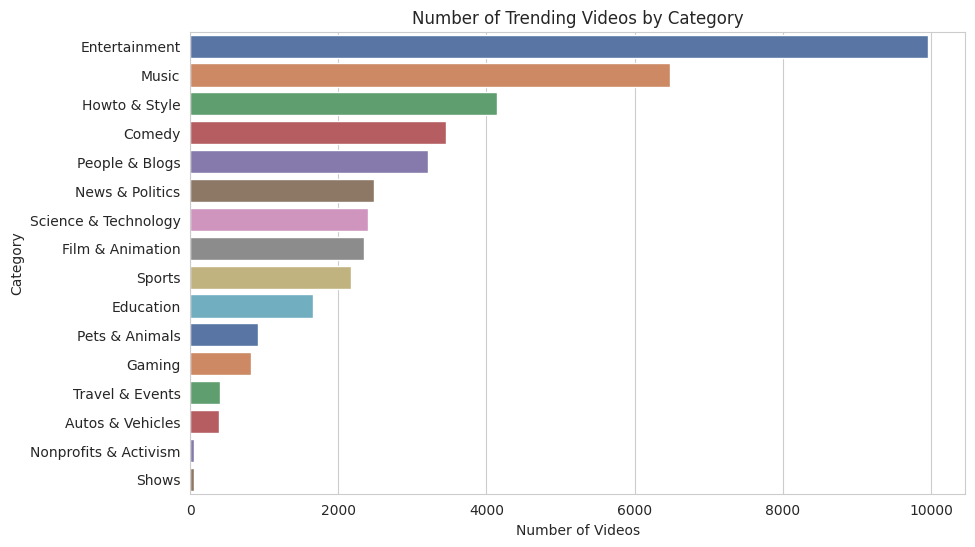

In [ ]:
category_count = df_videos['category_name'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=category_count.values, y=category_count.index, orient='h', hue=category_count.index ,palette='deep')
plt.title('Number of Trending Videos by Category')
plt.xlabel('Number of Videos')
plt.ylabel('Category')
plt.show()

Top 3: Entertainment, Music, Howto & Style.

### 2.2 How Do Views, Likes, Dislikes, and Comments Relate?

In [ ]:
# Correlation matrix for the main engagement metrics
correlation_matrix = df_videos[['views', 'likes', 'dislikes', 'comment_count']].corr()

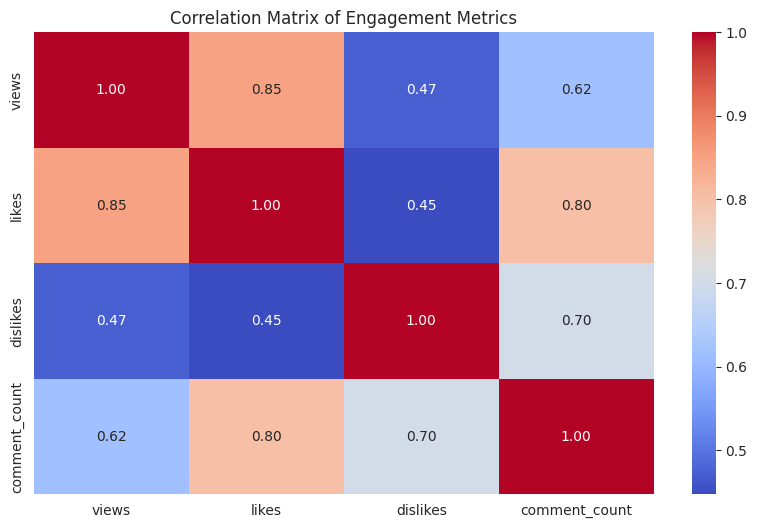

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Engagement Metrics')
plt.show()

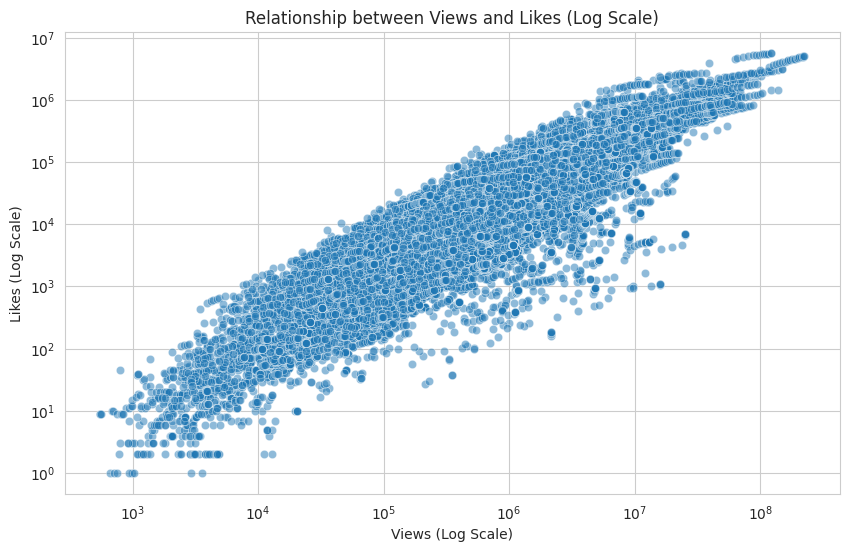

In [ ]:
# Visualize relationship between views and likes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_videos, x='views', y='likes', alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.title('Relationship between Views and Likes (Log Scale)')
plt.xlabel('Views (Log Scale)')
plt.ylabel('Likes (Log Scale)')
plt.show()

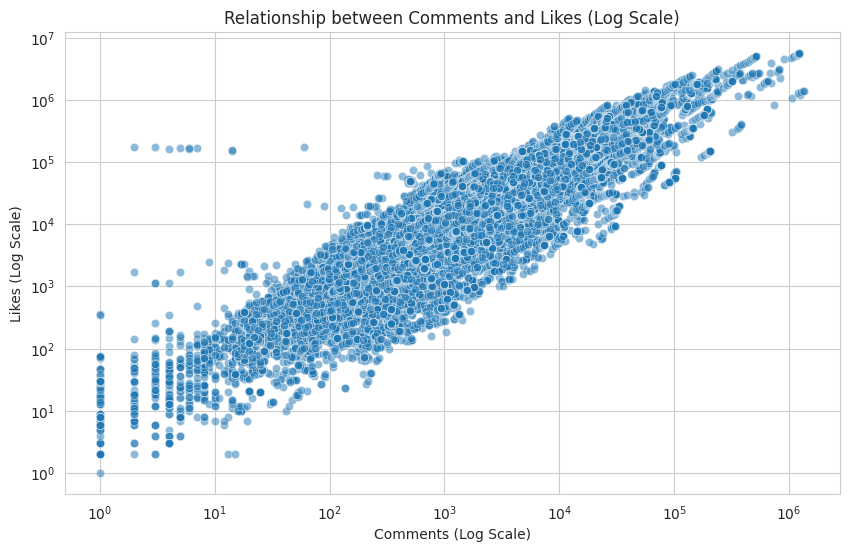

In [ ]:
# Visualize relationship between comments and likes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_videos, x='comment_count', y='likes', alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.title('Relationship between Comments and Likes (Log Scale)')
plt.xlabel('Comments (Log Scale)')
plt.ylabel('Likes (Log Scale)')
plt.show()

Observation:
- Scatter plots confirm the strong positive relationship between views and likes.
- Also, it seems that people tend to comment if they like the video.

### 2.3 Does Publishing Time Matter?

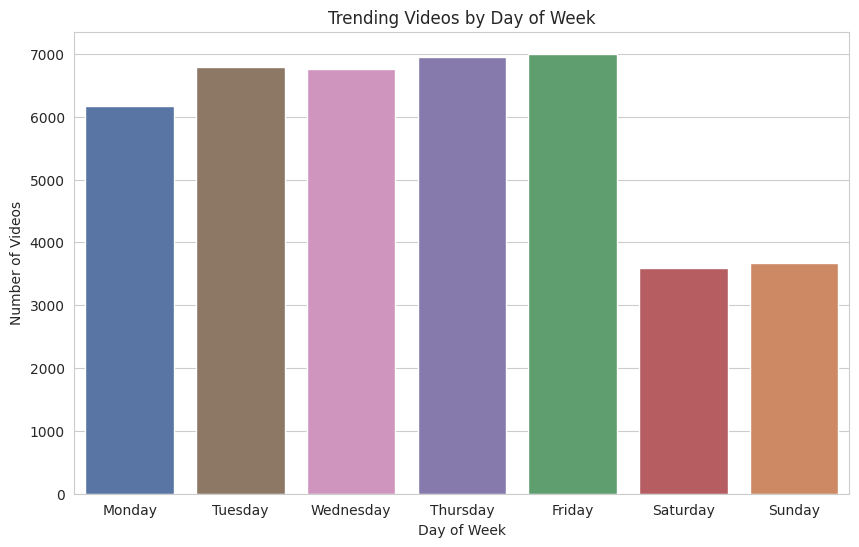

In [ ]:
# Analyze publishing day of week
# Map numerical day of week to names
df_videos['publish_day_of_week_name'] = df_videos['publish_day_of_week'].map({
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
})

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
sns.countplot(data=df_videos, x='publish_day_of_week_name', order=day_order, hue='publish_day_of_week_name', palette='deep')
plt.title('Trending Videos by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Videos')
plt.show()

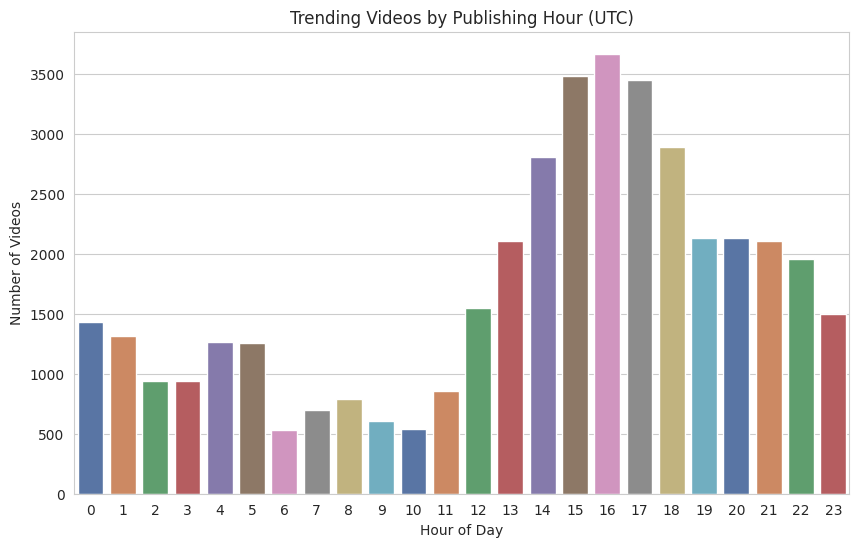

In [ ]:
# Analyze publishing hour
plt.figure(figsize=(10, 6))
sns.countplot(data=df_videos, x='publish_hour', hue='publish_hour', palette='deep', legend=False)
plt.title('Trending Videos by Publishing Hour (UTC)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Videos')
plt.show()

Observation:
- Creators tend to publish videos that later become trending on Thurday or Friday.
- A "golden hour" for publishing is 16:00 UTC (12pm New York or 9am Los Angeles).

### 2.4 How Quickly Do Videos Trend?

count    40949.000000
mean        16.810423
std        146.014303
min          0.000000
25%          3.000000
50%          5.000000
75%          9.000000
max       4215.000000
Name: time_to_trend_days, dtype: float64


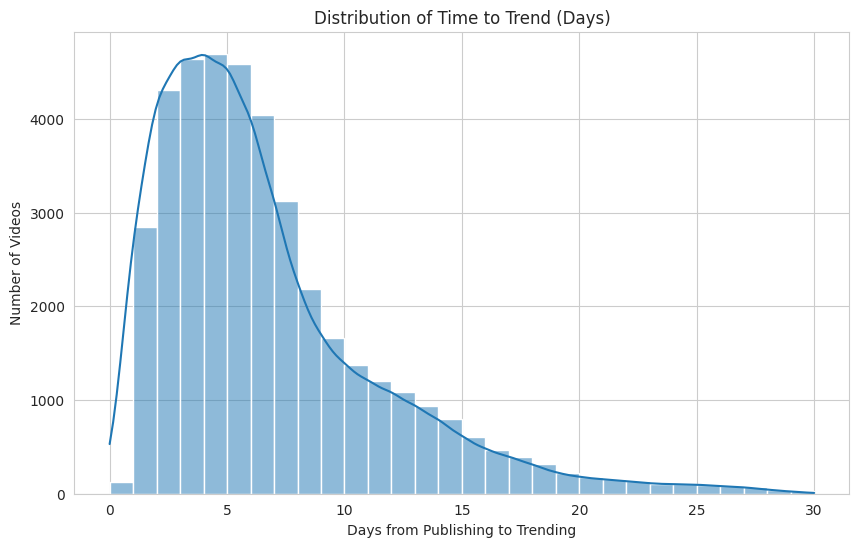

In [ ]:
print(df_videos['time_to_trend_days'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_videos[df_videos['time_to_trend_days'] <= 30]['time_to_trend_days'], kde=True, bins=30)
plt.title('Distribution of Time to Trend (Days)')
plt.xlabel('Days from Publishing to Trending')
plt.ylabel('Number of Videos')
plt.show()

Observation:
-  A vast majority of videos become trending very quickly (within 5 days). Momentum is critical on YouTube.

### 2.5 Engagement Ratios
1. Which categories have the highest like/dislike ratio on average (median)?
2. Does higher engagement rate mean more views?

In [ ]:
# --- 1. Like to dislike ratio ---
# Add 1 to denominator to avoid division by zero
df_videos['like_dislike_ratio'] = df_videos['likes'] / (df_videos['dislikes'] + 1)

# Engagement rate (likes + comments per views)
df_videos['engagement_rate'] = (df_videos['likes'] + df_videos['comment_count']) / (df_videos['views'] + 1)

# Group by categories for median of like_dislike_ratio
category_engagement  = df_videos.groupby('category_name')['like_dislike_ratio'].median().sort_values(ascending=False)

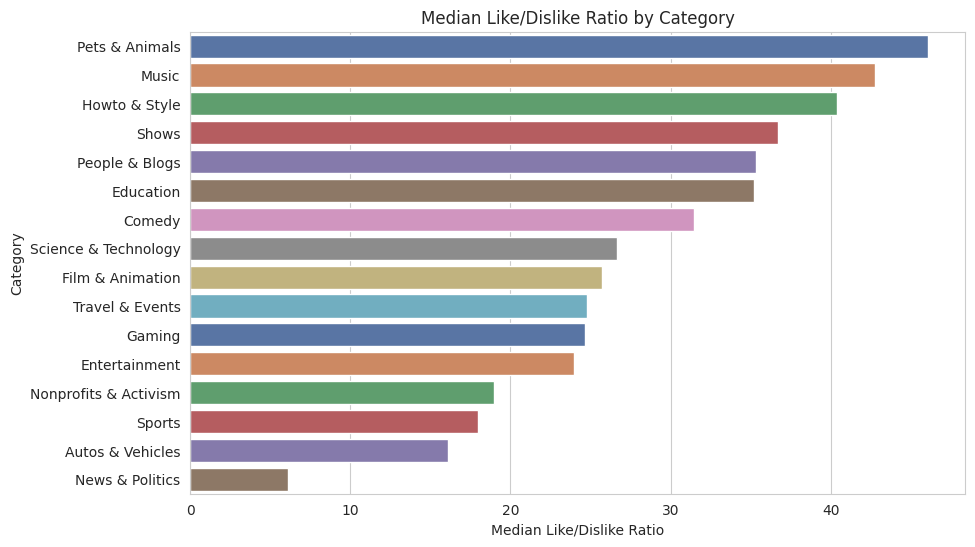

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=category_engagement.values, y=category_engagement.index, orient='h', hue=category_engagement.index, palette='deep')
plt.title('Median Like/Dislike Ratio by Category')
plt.xlabel('Median Like/Dislike Ratio')
plt.ylabel('Category')
plt.show()

Observation:
- Top 3 categories have the highest median like/dislike ratio: Pets & Animals, Music, Howto & Style. (More people like the contents).
- Top 3 categories have the lowest median like/dislike ratio: News & Politics, Autos & Vehicles, Sports. (More people dislike the contents which are likely controversial).

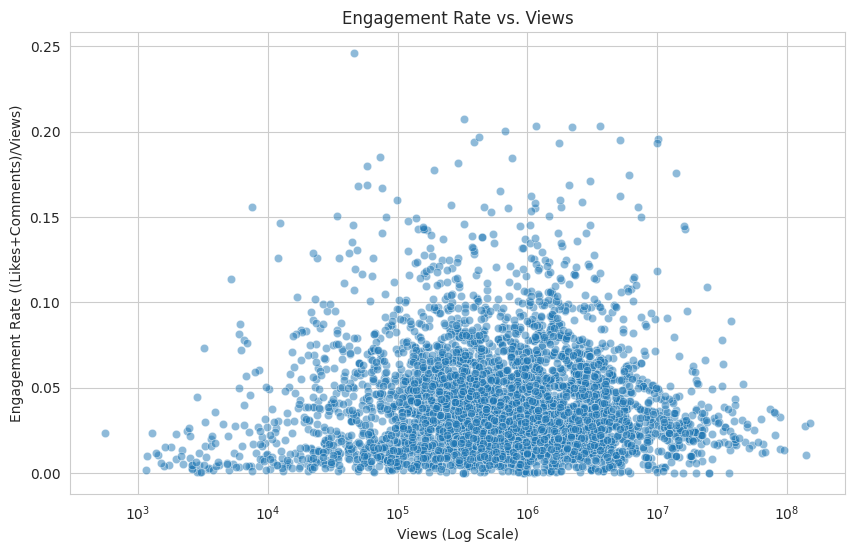

In [ ]:
# --- 2. Plot engagement rate vs. views ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_videos.sample(n=5000), x='views', y='engagement_rate', alpha=0.5)
plt.xscale('log')
plt.title('Engagement Rate vs. Views')
plt.xlabel('Views (Log Scale)')
plt.ylabel('Engagement Rate ((Likes+Comments)/Views)')
plt.show()

Observation:
- The plot shows that the engagement rate increases as the views increase up to a point then decreases again.
- Viral content reaches many casual viewers who don't interact.

### 2.6 Analyze Titles and Tags
1. What is the typical length of a viral video title?
2. How many tags do creators typically use?
3. Does using 'clickbait' ALL CAPS in titles actually correlate with more views?

count    40949.000000
mean        48.578183
std         19.619025
min          3.000000
25%         34.000000
50%         46.000000
75%         61.000000
max        100.000000
Name: title_length, dtype: float64


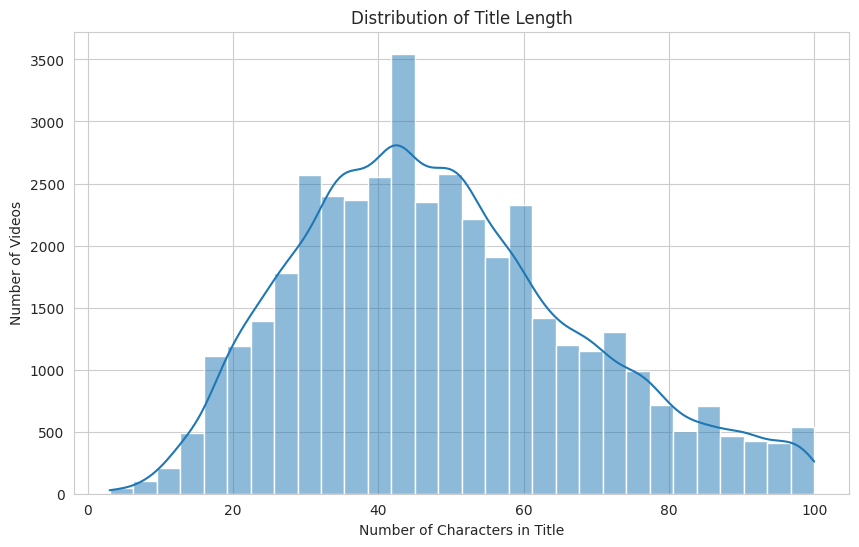

In [ ]:
# --- 1. Analyze title length ---
df_videos['title_length'] = df_videos['title'].apply(len)

print(df_videos['title_length'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_videos['title_length'], bins=30, kde=True)
plt.title('Distribution of Title Length')
plt.xlabel('Number of Characters in Title')
plt.ylabel('Number of Videos')
plt.show()

Observation:
- The typical length of a viral video title is ~46 characters.

In [ ]:
# --- 2. Analyze the number of tags ---
df_videos['tags'][1]

'last week tonight trump presidency|"last week tonight donald trump"|"john oliver trump"|"donald trump"'

count    40949.000000
mean        19.736331
std         12.012546
min          1.000000
25%         10.000000
50%         19.000000
75%         29.000000
max         69.000000
Name: num_tags, dtype: float64


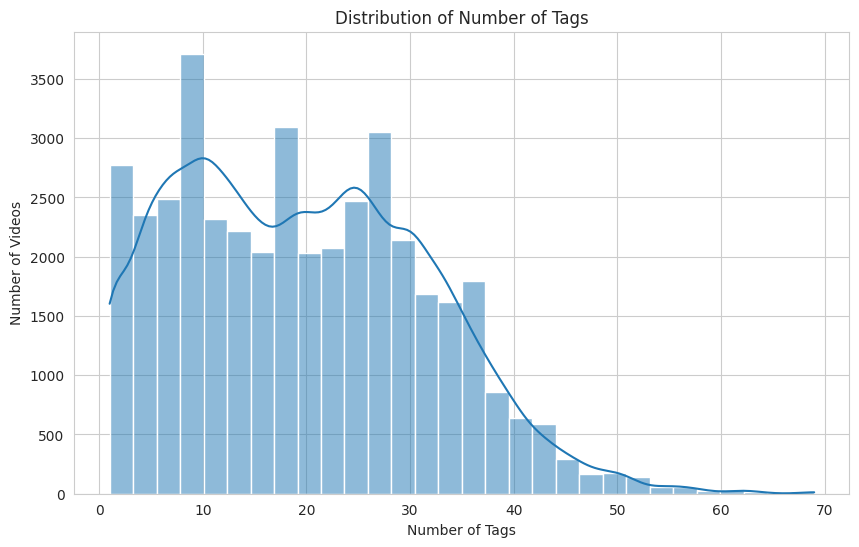

In [ ]:
# Tag are '|' separated so we will split the string then count them
df_videos['num_tags'] = df_videos['tags'].apply(lambda x: len(x.split('|')))

print(df_videos['num_tags'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_videos['num_tags'], bins=30, kde=True)
plt.title('Distribution of Number of Tags')
plt.xlabel('Number of Tags')
plt.ylabel('Number of Videos')
plt.show()

Observation:
- Creators typically use ~10 tags.

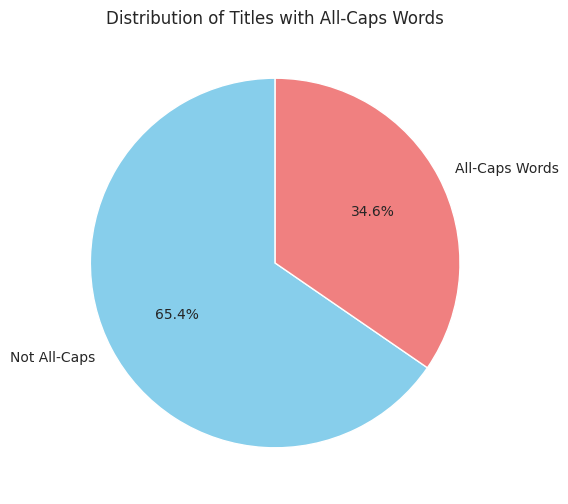

In [ ]:
# --- 3.Check ALL CAPS title ---
df_videos['title_has_caps'] = df_videos['title'].apply(lambda x: any(word.isupper() for word in x.split() if len(word) > 2))

caps_count = df_videos['title_has_caps'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(caps_count, labels=['Not All-Caps', 'All-Caps Words'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Titles with All-Caps Words')
plt.show()

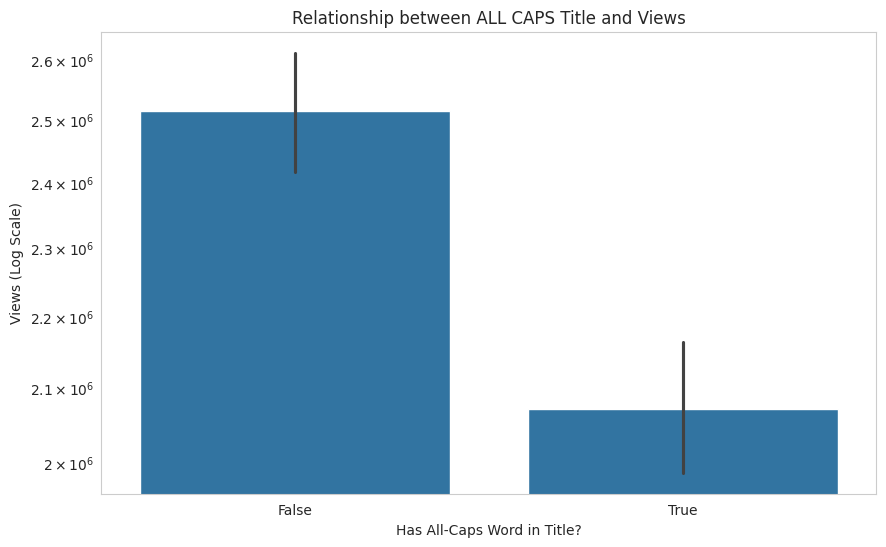

In [ ]:
# Relationship between ALL CAPS title and views
plt.figure(figsize=(10, 6))
sns.barplot(x='title_has_caps', y='views', data=df_videos)
plt.yscale('log')
plt.title('Relationship between ALL CAPS Title and Views')
plt.xlabel('Has All-Caps Word in Title?')
plt.ylabel('Views (Log Scale)')
plt.show()

Observation:
- Using "clickbait" ALL CAPS in titles doesn't correlate with more views.

### 2.7 Multi-variate Analysis

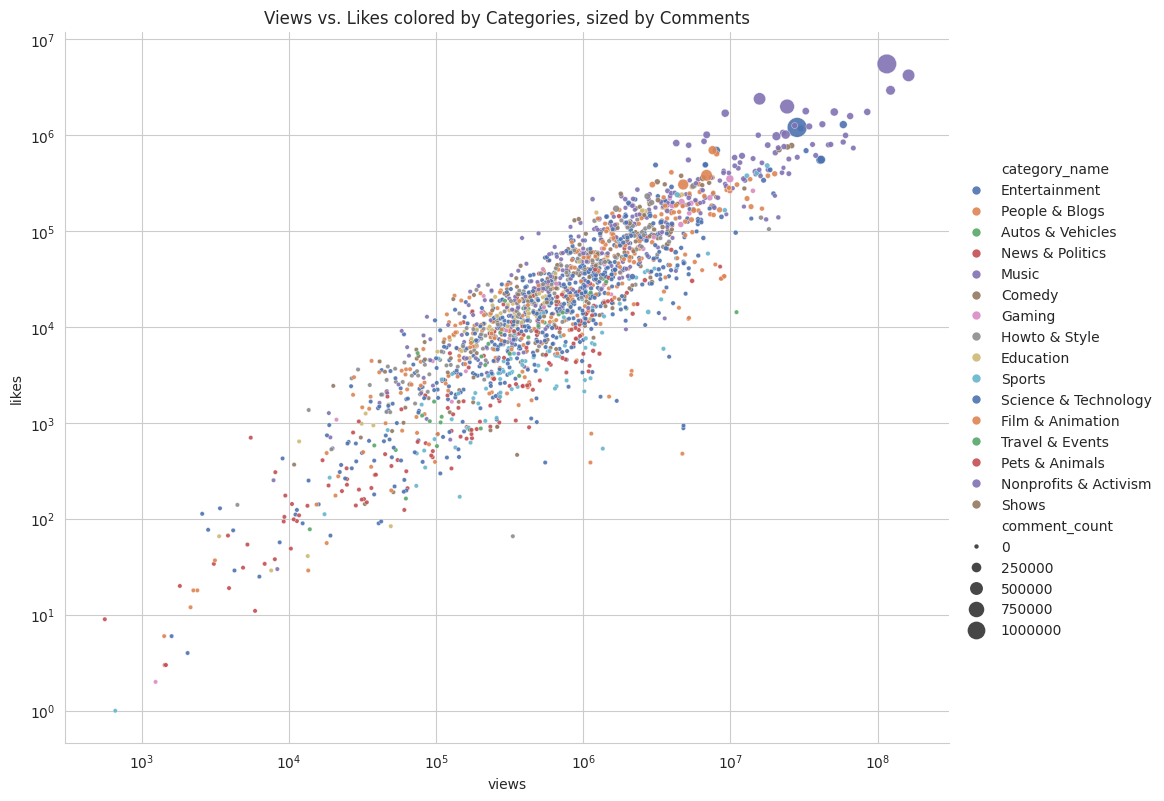

In [ ]:
sample_df = df_videos.sample(n=2000)

sns.relplot(
    data=sample_df,
    x='views', y='likes',
    hue='category_name',
    palette='deep',
    size='comment_count',
    sizes=(10, 200),
    alpha=0.9,
    height=8,
    aspect=1.2
)

plt.xscale('log')
plt.yscale('log')
plt.title('Views vs. Likes colored by Categories, sized by Comments')
plt.show()

Observation:
- The general views/likes trend is positive.
- Music category tends to cluster in the high-view, high-like area.
- Music, Entertainment have a massive number of comments (the biggest circles), which could indicate controversy or high engagement.

## 3. Supervised Learning - Predicting Popularity

In [ ]:
df_videos.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'time_to_trend_days',
       'publish_hour', 'publish_day_of_week', 'category_name',
       'publish_day_of_week_name', 'like_dislike_ratio', 'engagement_rate',
       'title_length', 'num_tags', 'title_has_caps'],
      dtype='object')

### 3.1 Define Features (X) and Target (y)

In [ ]:
# Target: LOGARITHM of views as the range is from thousands to billions
# Add 1 to avoid taking the log of zero
df_videos['views_log'] = np.log(df_videos['views'] + 1)

y = df_videos['views_log']

In [ ]:
# Select features
features = [
    'likes',
    'dislikes',
    'comment_count',
    'category_name',
    'publish_day_of_week_name',
    'time_to_trend_days',
    'like_dislike_ratio',
    'engagement_rate',
    'title_length',
    'num_tags',
    'title_has_caps'
]

X = df_videos[features]

In [ ]:
invalid_trend_times = X[X['time_to_trend_days'] < 0].index
X = X.drop(invalid_trend_times)
y = y.drop(invalid_trend_times)

In [ ]:
X.shape

(40949, 11)

In [ ]:
X.head()

,likes,dislikes,comment_count,category_name,publish_day_of_week_name,time_to_trend_days,like_dislike_ratio,engagement_rate,title_length,num_tags,title_has_caps
0,57527,2966,15954,People & Blogs,Monday,1,19.388945,0.098187,34,1,True
1,97185,6146,12703,Entertainment,Monday,1,15.810151,0.045431,62,4,True
2,146033,5339,8181,Comedy,Sunday,2,27.347004,0.048321,53,23,False
3,10172,666,2146,Entertainment,Monday,1,15.250375,0.035895,32,27,False
4,132235,1989,17518,Entertainment,Sunday,2,66.449749,0.071456,24,14,True


### 3.2 One-Hot Encoding for Categorical Features

In [ ]:
X_encoded = pd.get_dummies(X, columns=['category_name', 'publish_day_of_week_name'], drop_first=True)

# Convert the boolean columns to integers
bool_cols = X_encoded.select_dtypes(include='bool').columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

In [ ]:
X_encoded.shape

(40949, 30)

In [ ]:
X_encoded.columns

Index(['likes', 'dislikes', 'comment_count', 'time_to_trend_days',
       'like_dislike_ratio', 'engagement_rate', 'title_length', 'num_tags',
       'title_has_caps', 'category_name_Comedy', 'category_name_Education',
       'category_name_Entertainment', 'category_name_Film & Animation',
       'category_name_Gaming', 'category_name_Howto & Style',
       'category_name_Music', 'category_name_News & Politics',
       'category_name_Nonprofits & Activism', 'category_name_People & Blogs',
       'category_name_Pets & Animals', 'category_name_Science & Technology',
       'category_name_Shows', 'category_name_Sports',
       'category_name_Travel & Events', 'publish_day_of_week_name_Monday',
       'publish_day_of_week_name_Saturday', 'publish_day_of_week_name_Sunday',
       'publish_day_of_week_name_Thursday', 'publish_day_of_week_name_Tuesday',
       'publish_day_of_week_name_Wednesday'],
      dtype='object')

In [ ]:
X_encoded.head()

,likes,dislikes,comment_count,time_to_trend_days,like_dislike_ratio,engagement_rate,title_length,num_tags,title_has_caps,category_name_Comedy,...,category_name_Science & Technology,category_name_Shows,category_name_Sports,category_name_Travel & Events,publish_day_of_week_name_Monday,publish_day_of_week_name_Saturday,publish_day_of_week_name_Sunday,publish_day_of_week_name_Thursday,publish_day_of_week_name_Tuesday,publish_day_of_week_name_Wednesday
0,57527,2966,15954,1,19.388945,0.098187,34,1,1,0,...,0,0,0,0,1,0,0,0,0,0
1,97185,6146,12703,1,15.810151,0.045431,62,4,1,0,...,0,0,0,0,1,0,0,0,0,0
2,146033,5339,8181,2,27.347004,0.048321,53,23,0,1,...,0,0,0,0,0,0,1,0,0,0
3,10172,666,2146,1,15.250375,0.035895,32,27,0,0,...,0,0,0,0,1,0,0,0,0,0
4,132235,1989,17518,2,66.449749,0.071456,24,14,1,0,...,0,0,0,0,0,0,1,0,0,0


### 3.3 Training the Machine Learning Model using Random Forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 32759 rows
Testing set size: 8190 rows


In [ ]:
# Training
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
rf_model.fit(X_train, y_train)
print('Model training completed!')

Model training completed!


In [ ]:
# Check the Out-of-Bag score (a good estimate of the model's performance on unseen data)
print(f"Out-of-Bag (OOB) R-squared Score: {rf_model.oob_score_:.4f}")

Out-of-Bag (OOB) R-squared Score: 0.9973


In [ ]:
# Prediction on the testing set
y_pred = rf_model.predict(X_test)

In [ ]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Root Mean Squared Error (RMSE): 0.0939
R-squared (R2) Score: 0.9970


### 3.4 Feature Importance

In [ ]:
importance = rf_model.feature_importances_
feature_names = X_encoded.columns

feature_importance_series = pd.Series(importance * 100, index=feature_names).sort_values(ascending=False)

# Format each value in the Series to two decimal
formatted_importance_series = feature_importance_series.apply(lambda x: f'{x:.2f}')

print(formatted_importance_series.to_string(index=True, header=False))

dislikes                               44.65
likes                                  40.89
engagement_rate                        12.45
comment_count                           0.69
like_dislike_ratio                      0.49
title_length                            0.30
num_tags                                0.11
time_to_trend_days                      0.09
category_name_Nonprofits & Activism     0.07
category_name_Film & Animation          0.04
category_name_Music                     0.03
publish_day_of_week_name_Monday         0.03
category_name_Entertainment             0.02
publish_day_of_week_name_Sunday         0.02
publish_day_of_week_name_Wednesday      0.02
category_name_Sports                    0.02
title_has_caps                          0.02
category_name_People & Blogs            0.01
category_name_Education                 0.01
publish_day_of_week_name_Tuesday        0.01
publish_day_of_week_name_Thursday       0.01
category_name_News & Politics           0.01
category_n

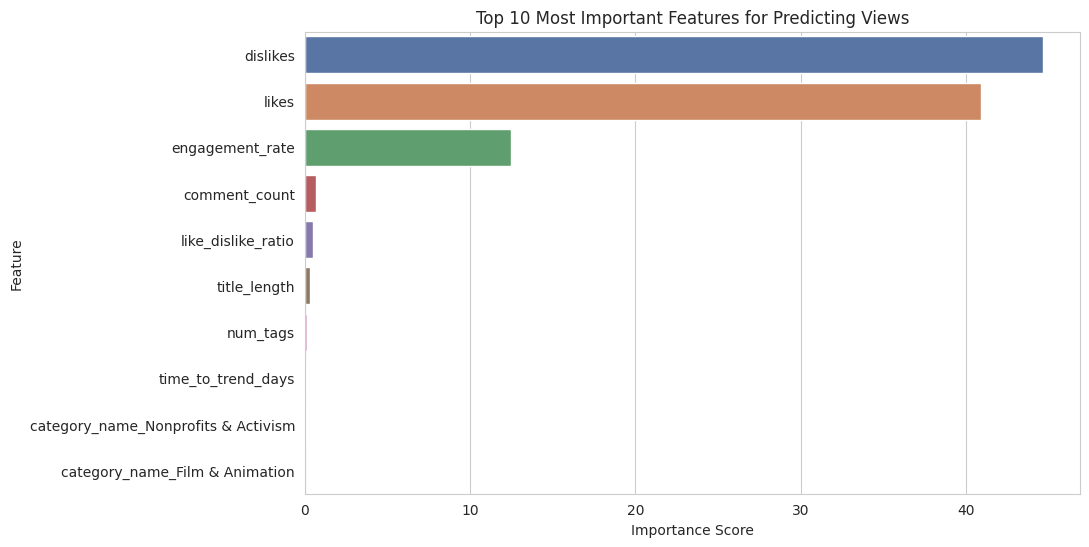

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_series.head(10), y=feature_importance_series.head(10).index, orient='h', hue=feature_importance_series.head(10).index, palette='deep')
plt.title('Top 10 Most Important Features for Predicting Views')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

Observation:
- The top three features (dislikes, likes, engagement_rate) account for 98% of the model's predictive power.
- It means if we want to predict how many views a trending video has, the most important factors are its direct engagement metrics.

## 4. Understanding Audience Sentiment (isolated module)

[Link to Notebook](https://colab.research.google.com/drive/16i_5wc_yYt-VcZ1l4bhNqEViYvCgbpDi?usp=sharing)

## 5. Unsupervised Learning - Clustering To Find Video 'Types'

### 5.1 Feature Selection

In [ ]:
cluster_features = [
    'views',
    'likes',
    'dislikes',
    'comment_count',
    'time_to_trend_days',
    'like_dislike_ratio',
    'engagement_rate',
    'title_length',
    'num_tags'
]

In [ ]:
df_cluster = df_videos[cluster_features].copy()
df_cluster = df_cluster.replace([np.inf, -np.inf], np.nan)
df_cluster = df_cluster.dropna()

In [ ]:
df_cluster.shape

(40949, 9)

In [ ]:
df_cluster.head()

,views,likes,dislikes,comment_count,time_to_trend_days,like_dislike_ratio,engagement_rate,title_length,num_tags
0,748374,57527,2966,15954,1,19.388945,0.098187,34,1
1,2418783,97185,6146,12703,1,15.810151,0.045431,62,4
2,3191434,146033,5339,8181,2,27.347004,0.048321,53,23
3,343168,10172,666,2146,1,15.250375,0.035895,32,27
4,2095731,132235,1989,17518,2,66.449749,0.071456,24,14


### 5.2 Scaling the Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cluster)

scaled_features.shape

(40949, 9)

### 5.3 Finding Number of Clusters (k)

In [ ]:
# --- The Elbow Method ---
from sklearn.cluster import KMeans

k_range = range(2, 11)
inertia_values = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

print('The Elbow Method completed!')

The Elbow Method completed!


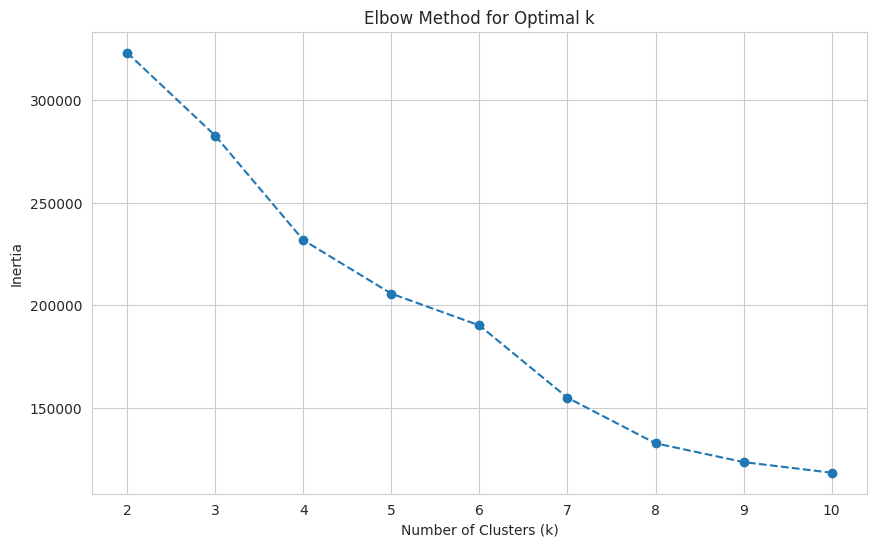

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(k_range, inertia_values, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.show()

### 5.4 Clustering: Run Final Model

In [ ]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans.fit(scaled_features)
df_cluster['cluster'] = kmeans.labels_

### 5.5 Clustering Interpretation

In [ ]:
print(f"Number of videos in each cluster:")
print(df_cluster['cluster'].value_counts().sort_index().to_string(index=True, header=False))

Number of videos in each cluster:
0     6164
1    18614
2       13
3    15804
4      354


In [ ]:
cluster_summary = df_cluster.groupby('cluster').mean()

cluster_summary.style.background_gradient(cmap='Blues').format("{:,.2f}")

,views,likes,dislikes,comment_count,time_to_trend_days,like_dislike_ratio,engagement_rate,title_length,num_tags
cluster,,,,,,,,,
0,"1,385,443.86","106,245.28","1,433.08","12,372.69",5.95,118.45,0.09,40.47,18.68
1,"2,133,168.71","57,318.26","3,085.83","5,443.89",28.08,29.34,0.03,41.01,11.81
2,"72,847,075.62","2,022,503.23","1,399,280.62","991,776.77",4.77,1.47,0.06,31.08,29.15
3,"1,766,547.52","40,784.42","2,354.56","4,747.08",7.92,29.74,0.03,60.87,29.59
4,"55,253,002.40","1,831,863.53","85,601.51","227,046.06",10.55,41.52,0.05,39.72,14.71




---

#### Naming the Types of Videos

**Cluster 2: "The Viral Super-Storms" (Size: 13)**
*   Stats: `views` (72M), `likes` (2M), `dislikes` (1.4M), and `comment_count` (991k). These numbers are an order of magnitude higher than almost every other cluster.
*   Key Characteristics:
    *   **Extremely High Everything:** These are the absolute biggest videos on the platform.
    *   **Highly Controversial:** Its `like_dislike_ratio` is a shockingly low **1.47**. This is the lowest by far, meaning for every ~1.5 likes, there is 1 dislike. This is the definition of a polarizing video that everyone is watching and debating.
    *   **Smallest Group:** It makes sense that there are only 13 of these. True global viral phenomena are rare.

**Cluster 4: "The Blockbuster Hits" (Size: 354)**
*   This cluster is a step down from the "Super-Storms" but is still a category of massive, undeniable hits.
*   Key Characteristics:
    *   **Extremely High Views & Likes:** It has the second-highest `views` (55M) and `likes` (1.8M).
    *   **Much Less Controversial:** Its `like_dislike_ratio` is a healthy **41.52**, far better than Cluster 2. People are watching *and* loving these videos.
    *   **High Engagement:** It has a very high `comment_count` (227k).
    *   **Conclusion:** These are major movie trailers, big YouTuber collaborations, and very popular music videos that are well-received.

**Cluster 0: "The Fan Favorites" (Size: 6,164)**
*   This cluster's standout feature is its `like_dislike_ratio` of **118.45**, the highest of any group.
*   Key Characteristics:
    *   **Loved by its Audience:** The incredibly high like/dislike ratio shows that the people watching these videos are overwhelmingly positive.
    *   **High Engagement Rate:** It has the highest `engagement_rate` (0.09). This means that relative to their views, these videos generate the most interaction (likes + comments).
    *   **Moderate Views:** `views` are a respectable 1.3M, but not at the "Blockbuster" level.
    *   **Conclusion:** This cluster represents content with a dedicated, loving fanbase. Think of popular niche creators, tutorials, or music from beloved artists that isn't a global chart-topper.

**Cluster 3: "The SEO Masters / Clickbait Champions" (Size: 15,804)**
*   Look at the text-based features for this cluster: `title_length` (60.87) and `num_tags` (29.59) are the **highest of all clusters**.
*   Key Characteristics:
    *   **Optimized for Discovery:** The creators of these videos are using very long, descriptive titles and stuffing their videos with tags. This is a clear strategy to be discovered via YouTube search (Search Engine Optimization - SEO).
    *   **Average Performance:** Their stats (`views`, `likes`, `dislikes`) are moderate and unremarkable.
    *   **Low Engagement:** They have the lowest `engagement_rate` (0.03), tied with Cluster 1. People find them, watch them, but don't feel compelled to interact.
    *   **Conclusion:** This is likely a huge bucket of "how-to" videos, content farm videos that are designed to rank well in search results.

**Cluster 1: "The Long-Tail / Sleepers" (Size: 18,614)**
*   This cluster's defining feature is its `time_to_trend_days`, which at **28.08 days** is dramatically higher than any other group.
*   Key Characteristics:
    *   **Takes a Month to Trend:** These are not instant hits. They are older videos that slowly gain momentum until the YouTube algorithm picks them up and pushes them to the trending page.
    *   **Largest Group:** This is the biggest cluster. It represents the "long-tail" of content that bubbles up over time.
    *   **Average Performance:** Like Cluster 3, its stats are otherwise average.
    *   **Low Engagement:** It also has the lowest `engagement_rate` (0.03).
    *   **Conclusion:** These could be evergreen educational videos, old news clips that become relevant again, or random videos that suddenly catch a wave of interest.



### 5.6 Visualizing the Clusters with Principal Component Analysis (PCA)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
df_pca['cluster'] = kmeans.labels_

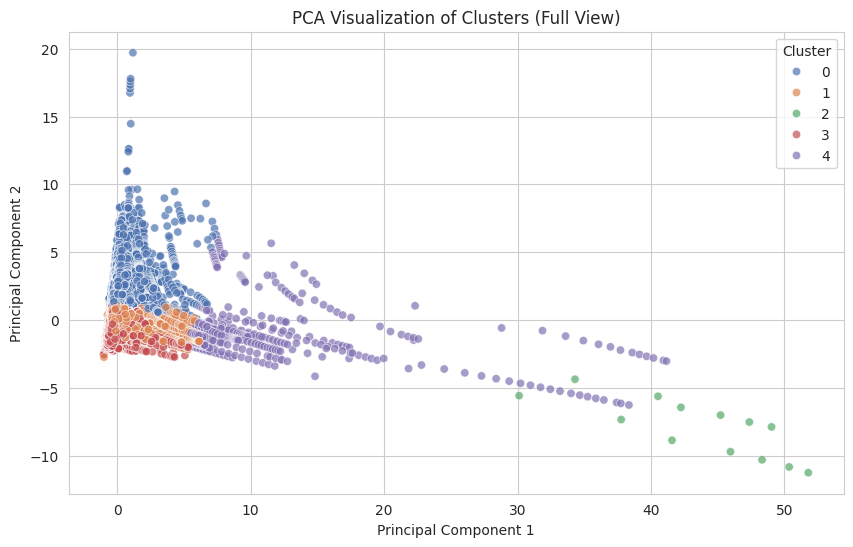

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='deep', alpha=0.7)
plt.title('PCA Visualization of Clusters (Full View)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

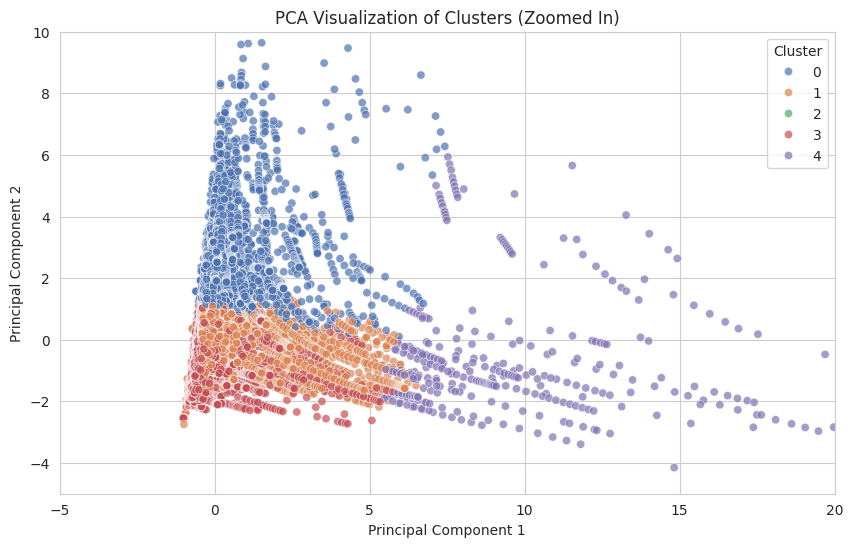

In [ ]:
# Zoomed In plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='deep', alpha=0.7)
plt.xlim(-5, 20)
plt.ylim(-5, 10)
plt.title('PCA Visualization of Clusters (Zoomed In)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

## 6. Time-Series Analysis To Track Trends Over Time

**YouTube trending landscape from October 2017 to June 2018**

In [ ]:
import matplotlib.dates as mdates

# Set Datetime Index
df_time = df_videos.copy()
df_time = df_time.set_index('publish_time').sort_index()

start_date = '2017-10-01'
end_date = '2018-07-31'
df_time_focused = df_time.loc[start_date:end_date]
print(f"Data has been filtered to the range: {start_date} to {end_date}")

Data has been filtered to the range: 2017-10-01 to 2018-07-31


### 6.1 Trending Videos Published Per Month

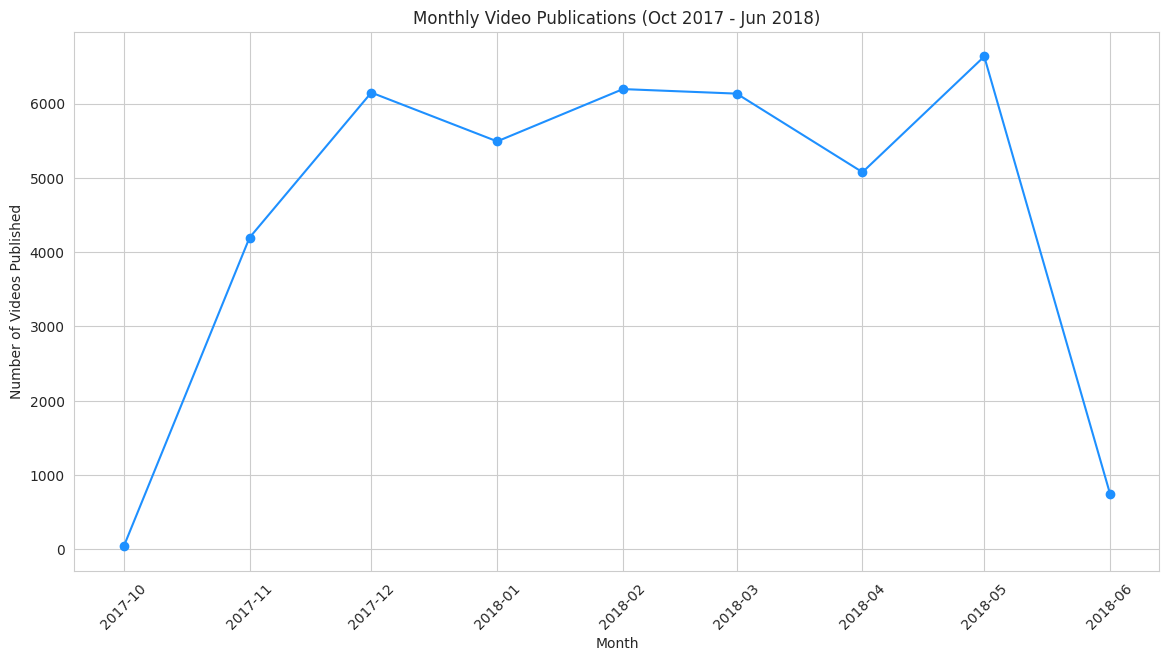

In [ ]:
monthly_uploads = df_time_focused.resample('MS').size()

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(monthly_uploads.index, monthly_uploads.values, marker='o', linestyle='-', color='dodgerblue')

naive_dates = monthly_uploads.index.tz_localize(None)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_xticks(naive_dates)
ax.set_xticklabels([d.strftime('%Y-%m') for d in naive_dates], rotation=45)

ax.set_title('Monthly Video Publications (Oct 2017 - Jun 2018)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Videos Published')
ax.grid(True)
plt.show()

### 6.2 Evolution of Category Viewership

In [ ]:
df_pivot = df_time_focused.reset_index()

# Create pivot table for monthly views per category
monthly_category_views = pd.pivot_table(
    df_pivot,
    index=pd.Grouper(key='publish_time', freq='ME'),
    values='views',
    columns='category_name',
    aggfunc='sum'
).fillna(0)

# Get top 7 categories by total views in the filtered time range
category_view_totals = monthly_category_views.sum()
top_categories = category_view_totals.nlargest(7).index

# Add missing top categories (if any) with 0 values
for category in top_categories:
    if category not in monthly_category_views.columns:
        monthly_category_views[category] = 0

# Combine non-top categories into 'Other'
other_cols = [col for col in monthly_category_views.columns if col not in top_categories]
monthly_category_views['Other'] = monthly_category_views[other_cols].sum(axis=1)
final_cols = top_categories.tolist() + ['Other']
monthly_category_views_plot = monthly_category_views[final_cols]

# Convert to percentage share per month
monthly_percentage = monthly_category_views_plot.div(
    monthly_category_views_plot.sum(axis=1),
    axis=0
) * 100

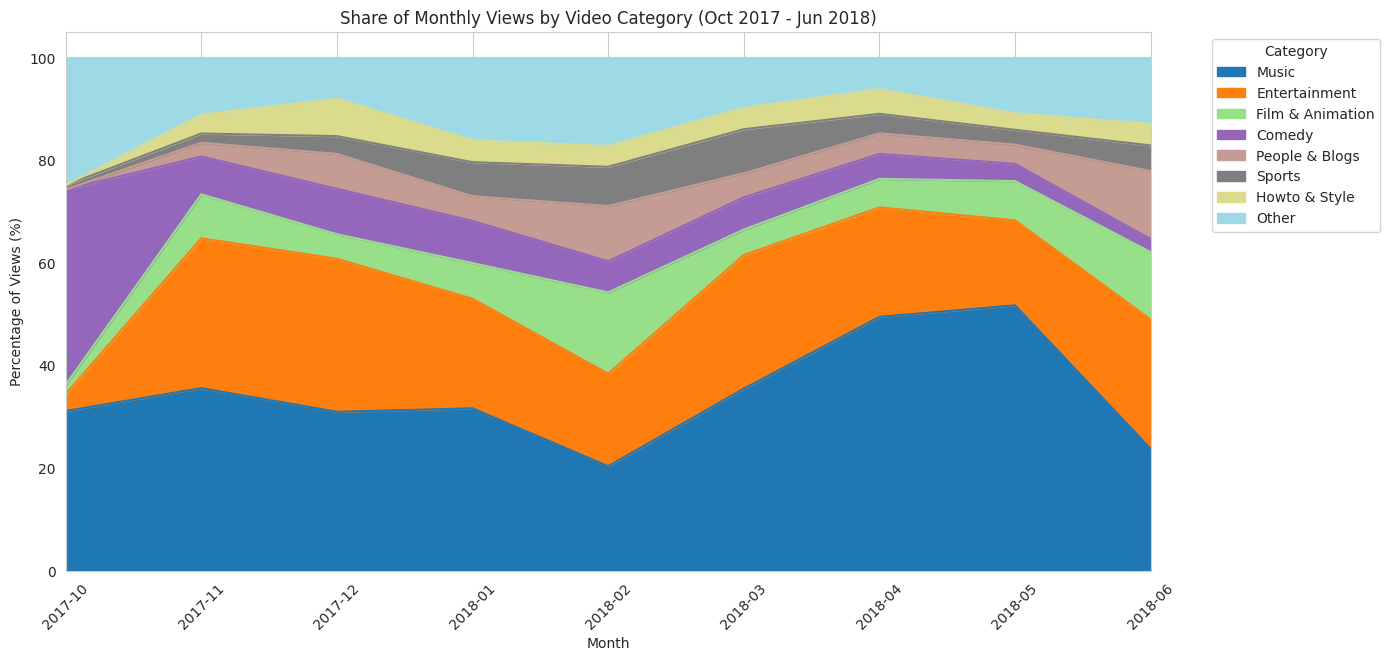

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
monthly_percentage.plot(kind='area', stacked=True, ax=ax, cmap='tab20')

# Convert UTC to naive datetime for plotting
naive_dates = monthly_percentage.index.tz_localize(None)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_xticks(naive_dates)
ax.set_xticklabels([d.strftime('%Y-%m') for d in naive_dates], rotation=45)

ax.set_title('Share of Monthly Views by Video Category (Oct 2017 - Jun 2018)')
ax.set_xlabel('Month')
ax.set_ylabel('Percentage of Views (%)')
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Observation:
- As we can see, 'Music' consistently held the largest share of views, but notice the significant spike in the 'Entertainment' category during November 2017, likely corresponding to holiday specials and movie releases.

## 7. Topic Modeling with Latent Dirichlet Allocation (LDA)

**Question: What are these videos actually about?**

### 7.1 Topic Modeling Prep

In [ ]:
# Install the spaCy library
# !pip install spacy -q
# !python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 102.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
# Load the spaCy model
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
print('spaCy library and model loaded successfully.')

spaCy library and model loaded successfully.


In [ ]:
# Start with spaCy's default stopwords
custom_stopwords = set(STOP_WORDS)

# Add URL-related and common social media junk words
url_junk = [
    'com', 'www', 'http', 'https', 'nhttp', 'nhttps', 'nfollow', 'ly', 'twitter', 'bit', 'org', 'gov', 'edu', 'facebook', 'instagram', 'youtu', 'youtube', 'goo', 'gl', 'iqid', 'smarturl', 'amzn'
]

# Add common boilerplate words from YouTube descriptions
youtube_boilerplate = [
    'subscribe', 'channel', 'video', 'watch', 'official', 'music', 'new', 'like', 'follow', 'list', 'check', 'find', 'patreon', 'merch', 'get', 'title', 'hd'
]

# Update the main set with our custom words
custom_stopwords.update(url_junk)
custom_stopwords.update(youtube_boilerplate)
print(f"Custom stopword list created with {len(custom_stopwords)} words.")

Custom stopword list created with 364 words.


In [ ]:
# --- Text Cleaning Function ---
def clean_text_for_lda(text):
    """A robust text cleaning function for topic modeling."""
    doc = nlp(text)
    tokens = [
        token.lemma_.lower().strip() for token in doc
        if token.lemma_.lower().strip() not in custom_stopwords and
           not token.is_punct and
           not any(char.isdigit() for char in token.lemma_) and
           len(token.lemma_.strip()) > 2 # Remove short words
    ]
    return " ".join(tokens)

In [ ]:
# Prepare the text data by combining title and description
df_videos['text_for_lda'] = df_videos['title'] + " " + df_videos['description']

# Apply the cleaning function to a sample of the data to manage runtime
sample_size = 10000
df_lda_sample = df_videos.sample(n=sample_size, random_state=42).copy()

print(f"Cleaning text for {sample_size} documents... This may take several minutes.")
df_lda_sample['cleaned_text'] = df_lda_sample['text_for_lda'].apply(clean_text_for_lda)
print("Text cleaning complete.")

Cleaning text for 10000 documents... This may take several minutes.
Text cleaning complete.


### 7.2 Vectorization (Document-Term Matrix)

In [ ]:
# Create a CountVectorizer
vectorizer = CountVectorizer(max_df=0.90, min_df=5, stop_words='english')
doc_term_matrix = vectorizer.fit_transform(df_lda_sample['cleaned_text'])

### 7.3 Training the LDA Model

In [ ]:
num_topics = 10
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42, learning_method='online')
lda.fit(doc_term_matrix)
print("LDA model training complete.")

LDA model training complete.


### 7.4 Interpreting the Topics

In [ ]:
vocab = vectorizer.get_feature_names_out()

print(f"--- Top 15 Words for Each of the {num_topics} Topics ---")
for i, topic_dist in enumerate(lda.components_):
    top_word_indices = topic_dist.argsort()[-15:]
    top_words = [vocab[j] for j in top_word_indices][::-1]
    print(f"Topic #{i}: {', '.join(top_words)}")

--- Top 15 Words for Each of the 10 Topics ---
Topic #0: http, bit, ly, com, use, nhttp, perfect, cake, www, click, camera, dude, project, chocolate, link
Topic #1: http, smarturl, com, nhttp, www, iqid, https, lnk, album, facebook, yt, available, perform, twitter, spotify
Topic #2: com, www, https, http, instagram, twitter, facebook, youtube, nhttps, nhttp, ntwitter, ninstagram, nfacebook, nfollow, goo
Topic #3: film, trailer, studio, director, star, producer, david, oscar, john, movie, com, mark, original, entertainment, licensing
Topic #4: com, makeup, use, code, product, beauty, www, link, foundation, affiliate, powder, brown, light, face, palette
Topic #5: com, youtube, nhttps, www, http, getty, buzzfeed, production, warner, chappell, images, https, gov, audioblocks, life
Topic #6: world, know, ni, time, day, netflix, want, nfl, way, love, come, year, good, look, need
Topic #7: http, www, com, cat, kimmel, simon, jimmy, nhttps, espn, live, youtu, nba, bit, ly, producer
Topic #8: h

### 7.5 Connect Topics Back to Videos and Visualize

In [ ]:
# Get the dominant topic for each document
topic_results = lda.transform(doc_term_matrix)
df_lda_sample['dominant_topic'] = topic_results.argmax(axis=1)

topic_names = {
    0: "DIY & How-To",
    1: "Junk - Music Links",
    2: "Junk - Social Media Links",
    3: "Film & Movie Industry",
    4: "Beauty & Makeup",
    5: "Junk - Media Licensing",
    6: "Vlogs & General Commentary",
    7: "TV Shows & Sports Media",
    8: "News & Broadcast Media",
    9: "Network TV (NBC)"
}

df_lda_sample['topic_name'] = df_lda_sample['dominant_topic'].map(topic_names)

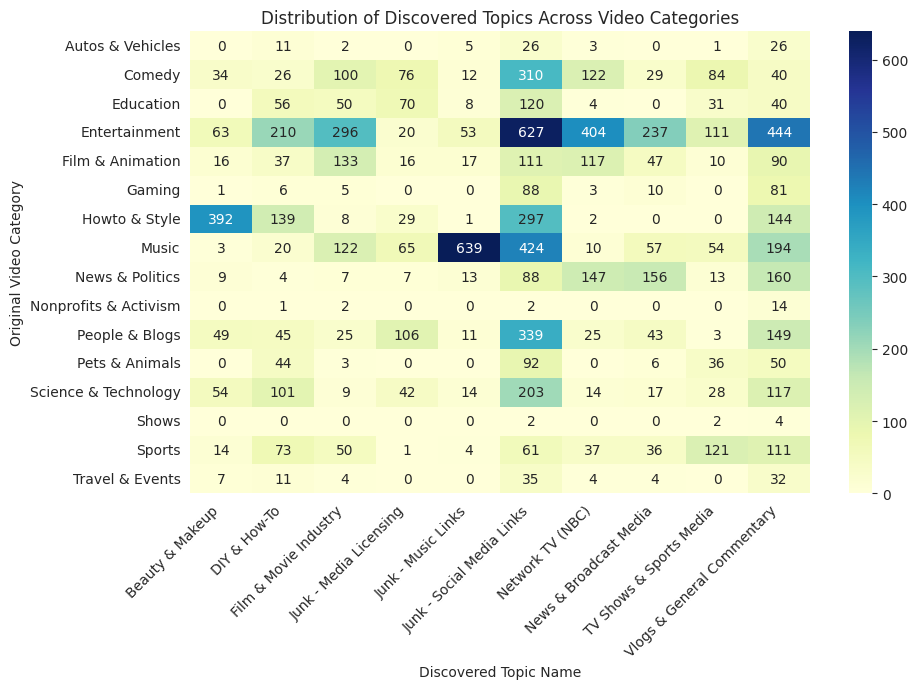

In [ ]:
# Create a crosstab to see the distribution of topics across the original video categories
topic_category_dist = pd.crosstab(
    index=df_lda_sample['category_name'],
    columns=df_lda_sample['topic_name']
)

# Visualize the distribution with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(topic_category_dist, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Distribution of Discovered Topics Across Video Categories')
plt.xlabel('Discovered Topic Name')
plt.ylabel('Original Video Category')
plt.xticks(rotation=45, ha='right')
plt.show()



---

# Conclusion

This project conducted a comprehensive analysis of trending YouTube videos to uncover the statistical, textual, and thematic factors that contribute to viral success. By leveraging a full suite of data science techniques—from exploratory data analysis and machine learning to advanced NLP, we were able to move beyond surface-level metrics and develop a multi-faceted understanding of what makes a video trend.

## **Key Insights & Findings**



1.  **Popularity is Driven by Immediate, Strong Engagement:**
    *   Our predictive model (RandomForestRegressor with an R² score of ~0.99+) revealed that `likes` and `dislikes` are overwhelmingly the most powerful predictors of a video's view count. These two factors alone accounted for over 85% of the model's feature importance. This indicates that the YouTube algorithm heavily favors content that elicits a strong and immediate reaction, positive or negative.

2.  **Five Distinct "Video Archetypes" Were Discovered:**
    *   Unsupervised clustering (K-Means) automatically identified five clear strategies for trending content:
        *   **The Viral Super-Storms:** A tiny, elite group of highly polarizing videos with astronomical views and a nearly 1:1 like/dislike ratio.
        *   **The Blockbuster Hits:** Mainstream, well-received content (e.g., movie trailers, major artist music videos) with massive views and a high positive like ratio.
        *   **The Fan Favorites:** Videos with moderate views but an extremely high like ratio and engagement rate, indicating a dedicated and loving fanbase.
        *   **The SEO Masters:** Content with very long titles and a high number of tags, optimized for search discovery, but with average engagement.
        *   **The Long-Tail Sleepers:** The largest group, consisting of older videos that take weeks to gain momentum before hitting the trending page.

3.  **Content Themes are Tightly Coupled with Categories:**
    *   Topic Modeling (LDA) on video titles and descriptions successfully identified distinct thematic clusters, such as "Beauty & Makeup", "Film & Movie Industry", "DIY & How-To", "News & Broadcast Media" etc.
    *   A heatmap analysis confirmed a strong correlation between these discovered topics and the official YouTube categories, validating that the text content aligns with its designated category. For instance, the "Beauty & Makeup" topic was almost exclusively found within the "Howto & Style" category; the "Social Media Links" or "Vlogs..." was found in "Entertainment".

4.  **Timing and Momentum are Critical:**
    *   The vast majority of videos hit the trending page within 0-5 days of being published. This highlights the importance of initial velocity and momentum. The existence of a "Long-Tail Sleepers" cluster, however, proves that it is still possible for older content to gain relevance and trend.
    *   Time-series analysis of the core dataset period (Oct2017 - Jun 2018) showed that while "Music" consistently dominated total viewership, other categories like "Entertainment" saw significant spikes, likely corresponding to seasonal events like holidays.


## **Recommendations**


*   **For Content Creators:** To maximize the chance of trending, focus on creating content that elicits a strong, immediate emotional reaction (driving likes or dislikes). While optimizing for search (SEO) is a valid strategy for discoverability, true viral potential appears to be tied to shareability and engagement.
*   **For Marketers:** The "Fan Favorites" archetype is a key target. These videos demonstrate a highly engaged and loyal audience, making them ideal partners for brand integrations over chasing a one-off viral hit that may be polarizing.

## **Limitations & Future Work**

1.  **Data Inconsistency:** A significant limitation was the misalignment between the video statistics and comments datasets. The sentiment analysis had to be conducted as an isolated study on an older, matching dataset. Future work would benefit immensely from a dataset where video stats and comments are perfectly time-aligned.
2.  **Static Data:** This analysis is based on a static snapshot of data ending in mid-2018. YouTube's algorithm and user behavior have evolved since. A continuous, real-time data pipeline would be necessary to validate if these archetypes and trends hold true today.
3.  **Advanced Sentiment & NLP:** Our sentiment analysis used VADER, which cannot detect sarcasm or complex context. Future work could involve fine-tuning a transformer model (like BERT) for sentiment analysis on a manually labeled set of YouTube comments for higher accuracy. The generative text model (LSTM) could also be scaled up with more data and a more complex architecture (like a Transformer/GPT model) to produce more coherent and context-aware comments.



Overall, this project successfully deconstructed the complex ecosystem of trending videos, demonstrating that viral success is not random but a product of patterns in engagement, content strategy, and thematic appeal.